## Predicted Building Damage: Venezuela Earthquakes (Catia La Mar) 2026

Following the June 2026 earthquakes near [Catia La Mar](https://en.wikipedia.org/wiki/Catia_La_Mar), Venezuela, the [Microsoft AI for Good Lab](https://www.microsoft.com/en-us/research/group/ai-for-good-research-lab/) ran their building-damage-assessment models over satellite imagery captured on 25 June 2026. The result is a set of building footprints, each with a *predicted damage* assessment, across the affected area.

This notebook explores the [`predicted-damage-venezuela-2026`](https://planetarycomputer.microsoft.com/dataset/predicted-damage-venezuela-2026) collection on the Planetary Computer. Unlike most collections, the data is published as a single **collection-level asset**: a [GeoPackage](https://www.geopackage.org/) of building footprints and their predicted damage. We'll open the STAC collection, inspect that asset, read it into a `geopandas.GeoDataFrame`, and explore the resulting table.

The collection mirrors the [Venezuela Earthquakes: Building Damage Assessment in Catia La Mar](https://data.humdata.org/dataset/venezuela-earthquakes-catia-la-mar) dataset on the Humanitarian Data Exchange (HDX) and is made available under the [CC-BY-4.0](https://creativecommons.org/licenses/by/4.0/) license.

> **Caveat:** the source imagery has orthorectification quality issues, which may cause footprints to be slightly misaligned with other basemaps.

In [16]:
import tempfile

import fsspec
import geopandas
import matplotlib.pyplot as plt
import planetary_computer
import pystac_client

### Data access

The datasets hosted by the Planetary Computer live in [Azure Blob Storage](https://learn.microsoft.com/azure/storage/blobs/). We use [`pystac-client`](https://pystac-client.readthedocs.io/) to open the [STAC API](https://planetarycomputer.microsoft.com/api/stac/v1) and pass `modifier=planetary_computer.sign_inplace` so that asset hrefs are automatically [signed](https://planetarycomputer.microsoft.com/docs/concepts/sas/) with a short-lived token. That token is what lets us read the data out of the Planetary Computer's private blob container.

In [12]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)
collection = catalog.get_collection("predicted-damage-venezuela-2026")
collection

<CollectionClient id=predicted-damage-venezuela-2026>

### The collection-level data asset

Most collections attach their data to individual STAC *items*. This collection instead exposes its data through a single **collection-level asset** named `data`. Let's see what that asset tells us.

In [13]:
asset = collection.assets["data"]

print("href:        ", asset.href.split("?")[0])
print("media type:  ", asset.media_type)
print("roles:       ", asset.roles)
print("title:       ", asset.title)
print("description: ", asset.description)
asset.extra_fields

href:         https://ai4edataeuwest.blob.core.windows.net/ai4good/venezuela2026/predicted_damage_catia_la_mar_footprints.gpkg
media type:   application/geopackage+sqlite3
roles:        ['data']
title:        Predicted building damage footprints
description:  GeoPackage of building footprints with predicted earthquake damage for Catia La Mar, Venezuela.


{'table:storage_options': {'account_name': 'ai4edataeuwest'}}

The collection uses the STAC [table](https://github.com/stac-extensions/table) extension to advertise its tabular schema. The published `table:columns` only documents the geometry column, so we'll discover the full set of attribute columns by reading the file itself.

In [14]:
collection.extra_fields.get("table:columns")

[{'name': 'geometry',
  'type': 'byte_array',
  'description': 'Building footprint polygons'}]

### Reading the GeoPackage

A GeoPackage is a single [SQLite](https://www.sqlite.org/) database file. Unlike a Parquet dataset it can't be efficiently range-read in place through GDAL's `/vsicurl/`, so we download the file (about 7.5 MB) to a local path with [`fsspec`](https://filesystem-spec.readthedocs.io/) and open it with `geopandas`. Because `asset.href` was already signed by our `sign_inplace` modifier, `fsspec` can fetch it directly.

In [17]:
local_path = f"{tempfile.gettempdir()}/predicted_damage_catia_la_mar_footprints.gpkg"
with fsspec.open(asset.href) as remote, open(local_path, "wb") as local:
    local.write(remote.read())

gdf = geopandas.read_file(local_path)

print(f"{len(gdf):,} building footprints")
print("CRS:", gdf.crs)
gdf.head()

30,761 building footprints
CRS: EPSG:32619


,id,damage_pct_0m,damage_pct_10m,damage_pct_20m,damaged,unknown_pct,geometry
0,0,0.0,0.0,0.0,0,0.0,"MULTIPOLYGON (((710092.494 1168126.764, 710099..."
1,1,0.0,0.0,0.0,0,0.0,"MULTIPOLYGON (((710083.254 1168141.343, 710089..."
2,2,0.0,0.0,0.0,0,0.0,"MULTIPOLYGON (((710093.315 1168144.58, 710096...."
3,3,0.0,0.0,0.0,0,0.0,"MULTIPOLYGON (((710092.207 1168146.808, 710096..."
4,4,0.0,0.0,0.0,0,0.0,"MULTIPOLYGON (((710089.598 1168149.193, 710090..."


### Exploring the attribute table

Each row is one building footprint (a `MultiPolygon`) together with the model's predicted-damage attributes:

| Column | Meaning |
| --- | --- |
| `id` | Unique integer identifier for the footprint. |
| `damage_pct_0m` | Predicted fraction (0–1) of the footprint classified as damaged. |
| `damage_pct_10m` | Same prediction, measured against the footprint buffered outward by 10 m. |
| `damage_pct_20m` | Same prediction, measured against the footprint buffered outward by 20 m. |
| `damaged` | Binary flag: `1` = predicted damaged, `0` = not. |
| `unknown_pct` | Fraction (0–1) of the footprint with an undetermined classification. |

The three `damage_pct_*` columns evaluate the prediction against progressively larger buffers around each footprint, which helps absorb the slight footprint/imagery misalignment noted in the caveat above.

In [18]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 30761 entries, 0 to 30760
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   id              30761 non-null  int64   
 1   damage_pct_0m   30761 non-null  float64 
 2   damage_pct_10m  30761 non-null  float64 
 3   damage_pct_20m  30761 non-null  float64 
 4   damaged         30761 non-null  int64   
 5   unknown_pct     30761 non-null  float64 
 6   geometry        30761 non-null  geometry
dtypes: float64(4), geometry(1), int64(2)
memory usage: 1.6 MB


In [19]:
gdf.drop(columns="geometry").describe()

,id,damage_pct_0m,damage_pct_10m,damage_pct_20m,damaged,unknown_pct
count,30761.000000,30761.000000,30761.000000,30761.000000,30761.000000,30761.000000
mean,15380.000000,0.168678,0.165920,0.163155,0.296934,0.062442
std,8880.080152,0.335758,0.277154,0.242305,0.456915,0.238094
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7690.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,15380.000000,0.000000,0.003631,0.043475,0.000000,0.000000
75%,23070.000000,0.065831,0.219206,0.232215,1.000000,0.000000
max,30760.000000,1.000000,1.000000,1.000000,1.000000,1.000000


How many buildings did the model flag as damaged? The `damaged` column gives a simple binary breakdown.

In [20]:
counts = gdf["damaged"].value_counts().rename({0: "not damaged", 1: "damaged"})
summary = counts.to_frame("buildings")
summary["percent"] = (summary["buildings"] / len(gdf) * 100).round(1)
summary

,buildings,percent
damaged,,
not damaged,21627,70.3
damaged,9134,29.7


### Footprint size

The data is in a projected CRS (`EPSG:32619`, UTM zone 19N), so geometry units are meters and we can compute each footprint's area in m² directly.

In [21]:
gdf["footprint_area_m2"] = gdf.geometry.area
gdf["footprint_area_m2"].describe().round(1)

count    30761.0
mean        98.6
std        364.5
min          0.1
25%         30.8
50%         56.2
75%         99.1
max      41996.4
Name: footprint_area_m2, dtype: float64

### Visualizing the predicted damage

Finally, a couple of quick overview maps to see the spatial pattern of the predictions. First, the footprints flagged as `damaged` (red) against the rest (gray).

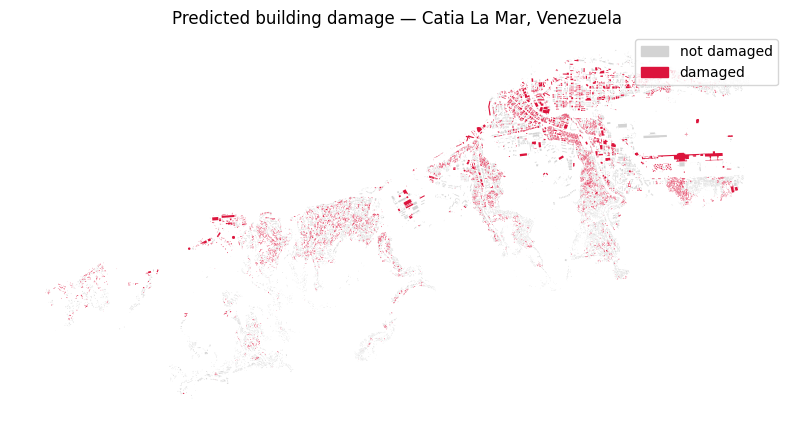

In [22]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(10, 10))
gdf[gdf["damaged"] == 0].plot(ax=ax, color="lightgray", linewidth=0)
gdf[gdf["damaged"] == 1].plot(ax=ax, color="crimson", linewidth=0)
ax.legend(
    handles=[
        Patch(color="lightgray", label="not damaged"),
        Patch(color="crimson", label="damaged"),
    ],
    loc="upper right",
)
ax.set_title("Predicted building damage — Catia La Mar, Venezuela")
ax.set_axis_off()

We can also map the continuous `damage_pct_20m` score to see *how* damaged each building is predicted to be, rather than just the binary flag.

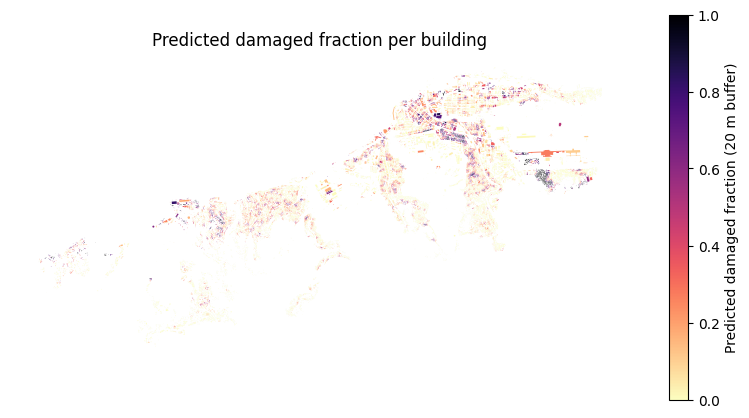

In [23]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(
    column="damage_pct_20m",
    cmap="magma_r",
    legend=True,
    legend_kwds={"label": "Predicted damaged fraction (20 m buffer)", "shrink": 0.5},
    linewidth=0,
    ax=ax,
)
ax.set_title("Predicted damaged fraction per building")
ax.set_axis_off()

### Next steps

- Read the [dataset overview](https://planetarycomputer.microsoft.com/dataset/predicted-damage-venezuela-2026) for the full methodology and caveats.
- See the [Reading tabular data](https://planetarycomputer.microsoft.com/docs/quickstarts/reading-tabular-data/) quickstart for more on working with tabular datasets on the Planetary Computer.
- Cross-reference these footprints with imagery collections (e.g. [Sentinel-2 L2A](https://planetarycomputer.microsoft.com/dataset/sentinel-2-l2a)) to inspect the affected area around the earthquakes.